*Предположение: коэффициент $\alpha$ один на весь детектор*

**План работ:**
- функция маскирования чет/нечет;
- функция оценки $\hat{\alpha}$;

**Тестирование:**
- $\hat{\alpha} - \alpha$ в идеальных условиях;
- $\hat{\alpha} - \alpha$ при наличие шума;
- $\hat{\alpha} - \alpha$ при наличие шума и спектральных линий;


In [1]:
# %matplotlib widget


from functools import partial
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

array([202.85098, 202.8539 , 202.85682, ..., 214.78896, 214.79188,
       214.79479])

In [90]:
dirpath = Path.cwd().parent / 'data' / 'lamp'

spectra = []
for filename in dirpath.iterdir():
    if 'Kinetics.' not in str(filename):
        continue

    datum = np.loadtxt(
        dirpath / filename,
        delimiter='\t',
        skiprows=1,
    )

    spectrum = EmittedSpectrum(
        intensity=datum[:,1:251].transpose(),
        wavelength=datum[:,0],
    )
    spectra.append(spectrum)

spectra = sorted(spectra, key=lambda spectrum: np.mean(spectrum.wavelength))

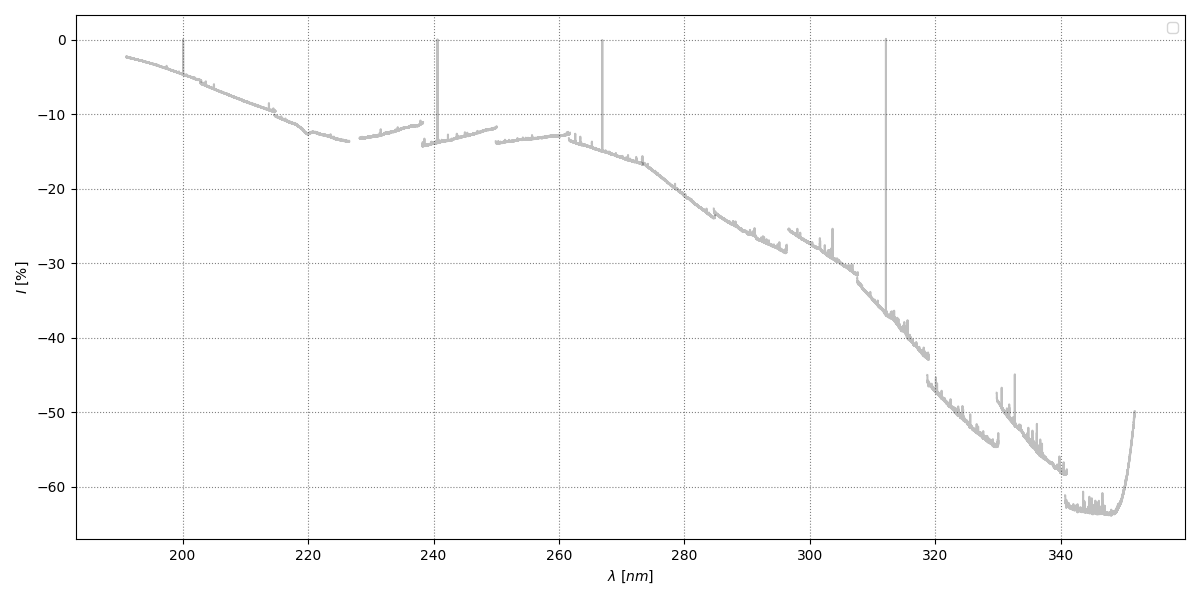

In [91]:
%matplotlib widget
# %matplotlib inline

if True:
    fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

    for spectrum in spectra:
        x = spectrum.wavelength
        y = -spectrum.intensity[0,:]
        ax.step(
            x, y,
            where='mid',
            color='black', alpha=.25,
        )

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$I$ [$\%$]')
    ax.grid(
        color='grey', linestyle=':',
    )

    ax.legend(loc='upper right')

    plt.show()


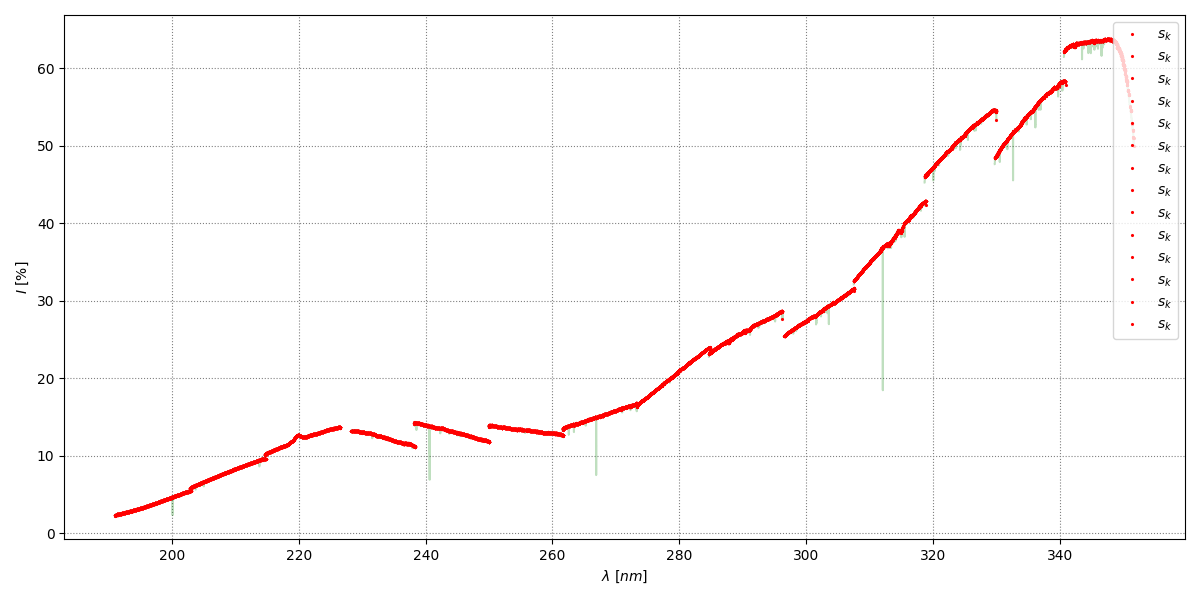

In [92]:
%matplotlib widget
# %matplotlib inline


fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)


masks = []
for spectrum in spectra:
    peaks = draft_blinks(
        spectrum=EmittedSpectrum(
            intensity=-convolve(np.mean(spectrum.intensity, axis=0), [.25, .5, .25], mode='mirror'),
        ),
        config=DraftBlinksConfig(
            n_counts_min=3,
            except_clipped_peak=False,
            except_sloped_peak=False,
            except_edges=True,
            amplitude_min=.1,
        ),
    )

    #
    mask = np.full(spectrum.n_numbers, True)
    for peak in peaks:
        lb, ub = peak.minima
        mask[lb:ub] = False

    masks.append(mask)

    #
    x = spectrum.wavelength
    y = convolve(np.mean(spectrum.intensity, axis=0), [.25, .5, .25], mode='mirror')
    ax.step(
        x, y,
        where='mid',
        color='green', alpha=.25,
    )

    x = spectrum.wavelength[mask]
    y = convolve(np.mean(spectrum.intensity, axis=0), [.25, .5, .25], mode='mirror')[mask]
    ax.plot(
        x, y,
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=2.5,
        label='$s_{k}$',
    )

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$I$ [$\%$]')
    ax.grid(
        color='grey', linestyle=':',
    )

    ax.legend(loc='upper right')

plt.show()


In [106]:
def calculate_loss(
    params: Array[float],
    spectrum: 'EmittedSpectrum',
    mask: Array[bool],
    smooth: Array[R],
) -> float:
    alpha, *_ = params

    effect = alpha + np.zeros(spectrum.n_numbers)

    corrected = spectrum.intensity.copy()
    corrected[0::2] /= 1 - effect[0::2]/2
    corrected[1::2] /= 1 + effect[1::2]/2

    noise = (corrected - smooth)[mask]
    return np.sum(noise**2)


def estimate_params(
    spectrum: 'EmittedSpectrum',
    mask: Array[bool],
) -> float:

    smooth = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')
    res = optimize.minimize(
        partial(
            calculate_loss,
            spectrum=spectrum,
            mask=mask,
            smooth=smooth,
        ),
        x0=[
            0,
        ],
        bounds=[
            (-1, +1),
        ],
        method='L-BFGS-B',
    )
    alpha, *_ = res['x']

    return alpha


In [128]:
window_size = 8

alpha_hats = []
for i, (spectrum, mask) in tqdm(enumerate(zip(spectra, masks))):

    n_chunks = spectrum.n_numbers // window_size + 1
    extra = 2

    alpha_hat = np.zeros(spectrum.n_numbers)
    for j in range(n_chunks):
        left = max((j - extra)*window_size, 0)
        right = min((j + extra + 1)*window_size, spectrum.n_numbers)

        alpha_hat[left:right] = estimate_params(
            spectrum=EmittedSpectrum(
                intensity=np.mean(spectrum.intensity[:,left:right], axis=0),
            ),
            mask=mask[left:right],
        )

    alpha_hats.append(alpha_hat)


14it [00:17,  1.27s/it]


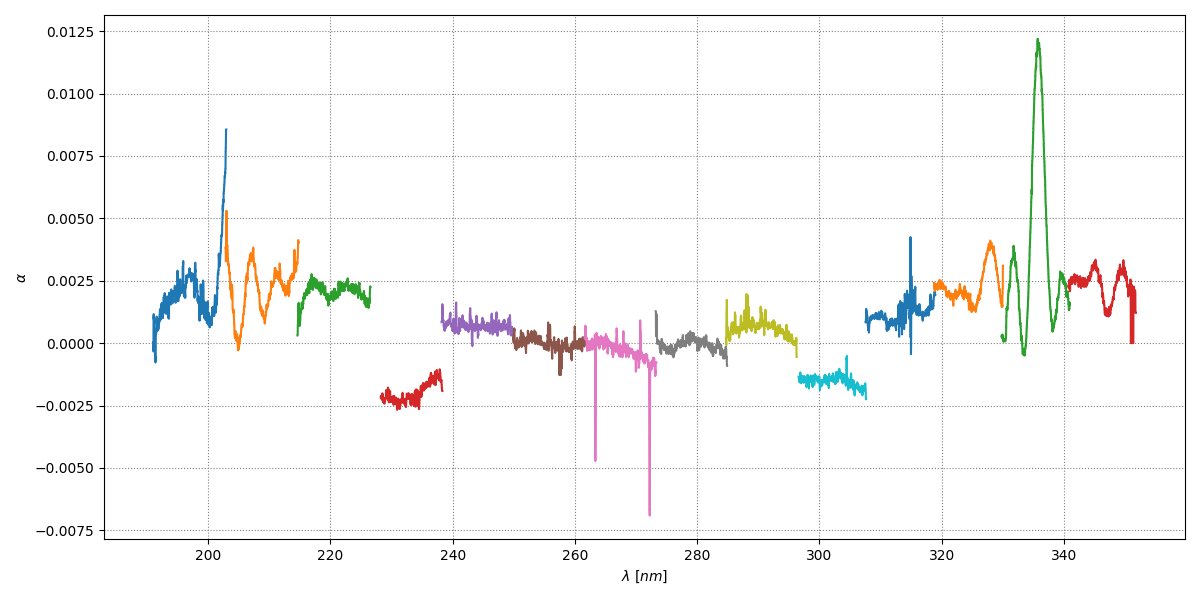

In [129]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

for i, (spectrum, alpha_hat) in enumerate(zip(spectra, alpha_hats)):
    x = spectrum.wavelength
    y = alpha_hat
    ax.plot(x, y, picker=True, pickradius=5)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$\alpha$')
ax.grid(color='grey', linestyle=':')

def on_pick(event):
    line = event.artist
    line.set_ydata(-1 * line.get_ydata())
    
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)

plt.show()

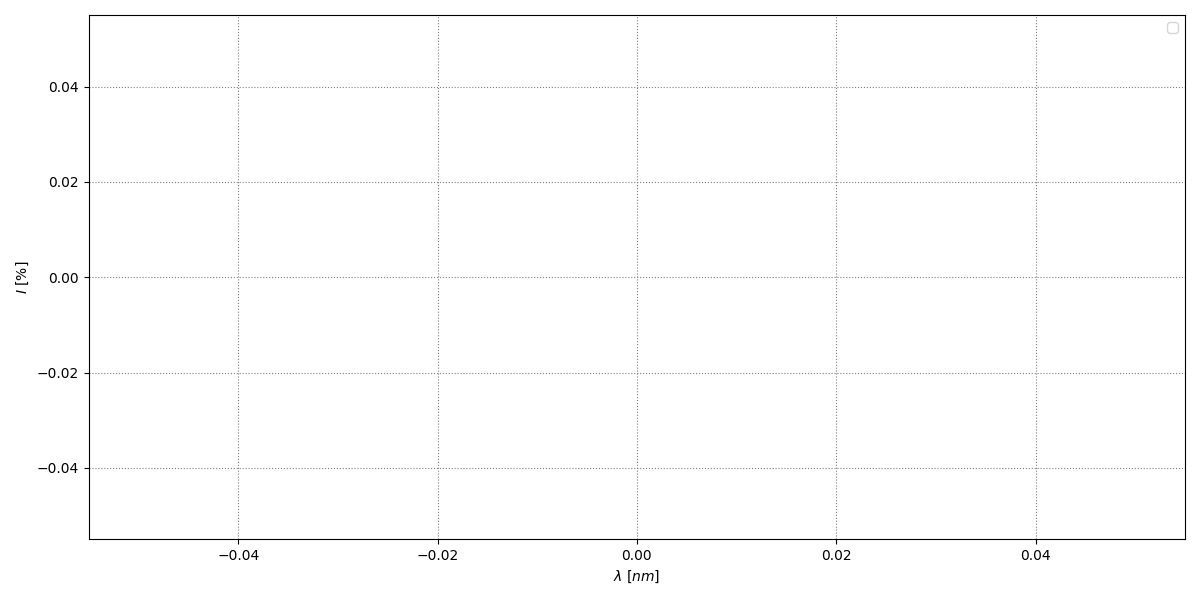

interactive(children=(IntSlider(value=0, description='Record:', max=249), Output()), _dom_classes=('widget-int…

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

plot_elements = []
for _ in range(len(spectra)):
    line_orig, = ax.step([], [], where='mid', color='black', alpha=.25)
    line_hat, = ax.step([], [], where='mid', color='black', alpha=.75, picker=True)
    line_diff, = ax.plot([], [], color='black', linestyle=':', alpha=1)
    plot_elements.append((line_orig, line_hat, line_diff))

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.legend(loc='upper right')

plt.show()


def update(idx):
    for i, (spectrum, alpha_hat, mask) in enumerate(zip(spectra, alpha_hats, masks)):
        line_orig, line_hat, line_diff = plot_elements[i]
        
        x = spectrum.wavelength
        y = spectrum.intensity[idx, :] # Используем индекс из ползунка
        
        # Обновляем фоновую линию
        line_orig.set_data(x, y)
        
        # Расчет y_hat и y_smooth
        y_smooth = np.convolve(y, [.25, .5, .25], mode='same') # упрощенно для примера
        try:
            effect = alpha_hat + np.zeros(spectrum.n_numbers)
            y_hat = y.copy()
            y_hat[0::2] /= 1 - effect[0::2]/2
            y_hat[1::2] /= 1 + effect[1::2]/2
            
            line_hat.set_data(x, y_hat)
            line_diff.set_data(x[mask], (y_hat - y_smooth)[mask])
        except:
            pass
            
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

# Обработчик клика для инверсии
def on_pick(event):
    line = event.artist
    line.set_ydata(line.get_ydata() * -1)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)

# Определяем максимальный индекс по axis=0
max_idx = spectra[0].n_times - 1

interact(update, idx=IntSlider(min=0, max=max_idx, step=1, value=0, description='Record:'));

In [ ]:
добавить поиск чет/нечет!